<a href="https://colab.research.google.com/github/gracenaomi1122/my-first-repo/blob/main/Exploratory_Data_Analysis_(EDA)_with_Pandas_Subjective.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Create or load data ---
df = pd.DataFrame({
    "category": [],
    "units_sold": [],
    "revenue": [],
})

# --- Plot 1: Histogram of units_sold (overall) ---
def plot_units_histogram(df):
    # Your implementation here
    pass

# --- Plot 2: Histogram of units_sold by category ---
def plot_units_histogram_hue(df):
    # Your implementation here
    pass

# --- Plot 3: Box plot of revenue by category ---
def plot_revenue_boxplot(df):
    # Your implementation here
    pass

# --- Plot 4: Scatter plot of units_sold vs revenue ---
def plot_scatter(df):
    # Your implementation here
    pass

# --- Outlier bounds ---
def compute_outlier_bounds(df):
    # Your implementation here
    pass

if __name__ == "__main__":
    plot_units_histogram(df)
    plot_units_histogram_hue(df)
    plot_revenue_boxplot(df)
    plot_scatter(df)
    compute_outlier_bounds(df)

Revenue outlier bounds:
Lower: -14280.50
Upper: 30451.50


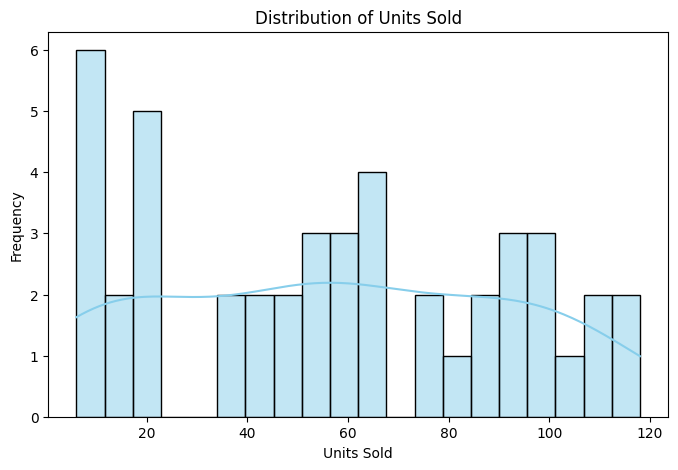

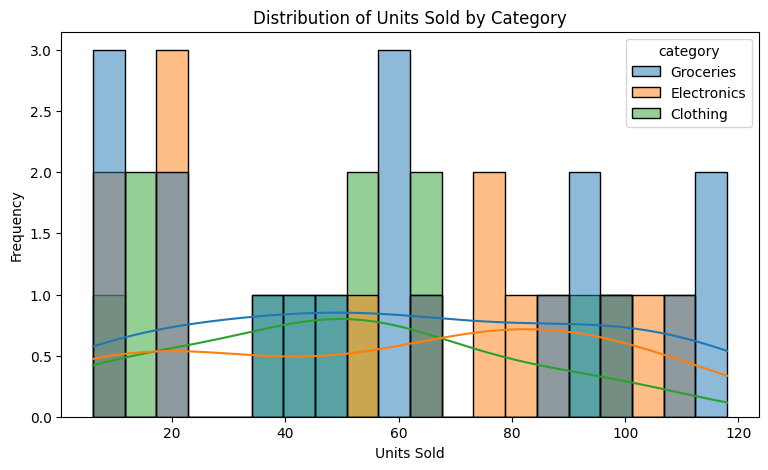

/tmp/ipykernel_2705/168729431.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


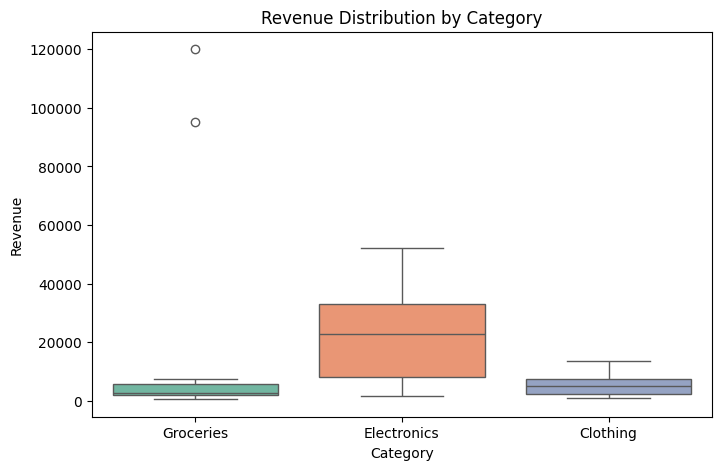

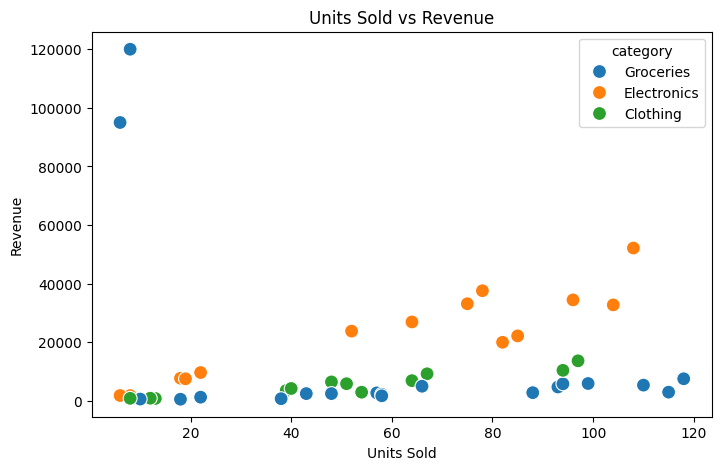

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create Synthetic Sales Dataset
np.random.seed(42)

n = 45

categories = ["Electronics", "Clothing", "Groceries"]

df = pd.DataFrame({
    "date": pd.date_range(start="2025-01-01", periods=n, freq="D"),
    "category": np.random.choice(categories, size=n),
    "units_sold": np.random.randint(5, 120, size=n),
    "discount_pct": np.random.uniform(0, 30, size=n).round(2)
})

# Generate revenue based on category
revenue = []

for cat, units in zip(df["category"], df["units_sold"]):
    if cat == "Electronics":
        revenue.append(units * np.random.randint(200, 500))
    elif cat == "Clothing":
        revenue.append(units * np.random.randint(50, 150))
    else:  # Groceries
        revenue.append(units * np.random.randint(20, 80))

df["revenue"] = revenue

# Add a few intentional outliers
df.loc[2, "revenue"] = 120000
df.loc[10, "revenue"] = 95000

# Compute IQR Outlier Bounds
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Revenue outlier bounds:")
print(f"Lower: {lower_bound:.2f}")
print(f"Upper: {upper_bound:.2f}")

# Plot 1: Histogram of units_sold
def plot_units_histogram(df):
    plt.figure(figsize=(8, 5))

    sns.histplot(df["units_sold"], bins=20, kde=True, color="skyblue")

    plt.title("Distribution of Units Sold")
    plt.xlabel("Units Sold")
    plt.ylabel("Frequency")

    plt.show()

# Plot 2: Histogram by Category
def plot_units_histogram_hue(df):
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df,
        x="units_sold",
        hue="category",
        bins=20,
        kde=True,
        multiple="layer"
    )

    plt.title("Distribution of Units Sold by Category")
    plt.xlabel("Units Sold")
    plt.ylabel("Frequency")

    plt.show()

# Plot 3: Revenue Box Plot
def plot_revenue_boxplot(df):
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="category",
        y="revenue",
        palette="Set2"
    )

    plt.title("Revenue Distribution by Category")
    plt.xlabel("Category")
    plt.ylabel("Revenue")

    plt.show()

# Plot 4: Scatter Plot
def plot_units_vs_revenue(df):
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="units_sold",
        y="revenue",
        hue="category",
        s=100
    )

    plt.title("Units Sold vs Revenue")
    plt.xlabel("Units Sold")
    plt.ylabel("Revenue")

    plt.show()
# Run All Plots
plot_units_histogram(df)
plot_units_histogram_hue(df)
plot_revenue_boxplot(df)
plot_units_vs_revenue(df)


Revenue outlier bounds → Lower: -16824.38, Upper: 43372.62


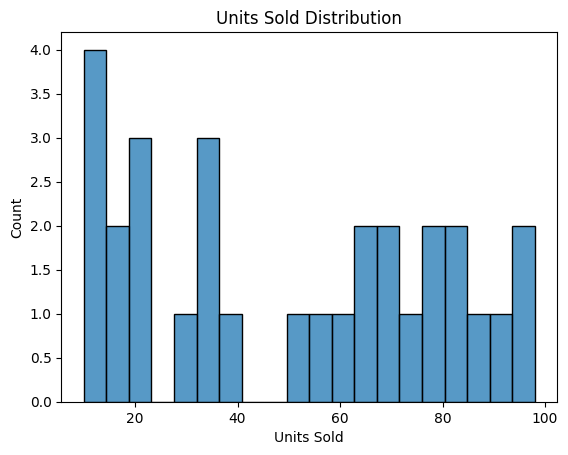

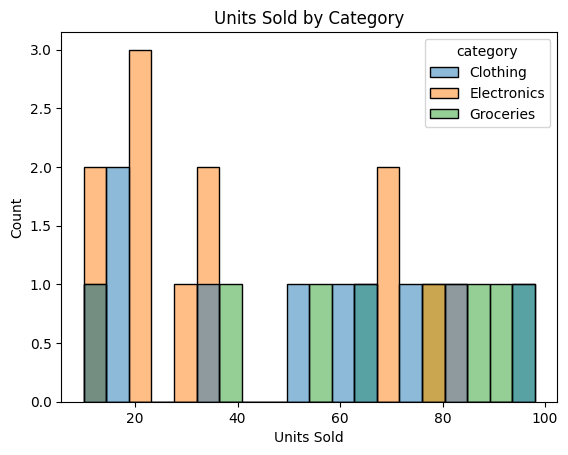

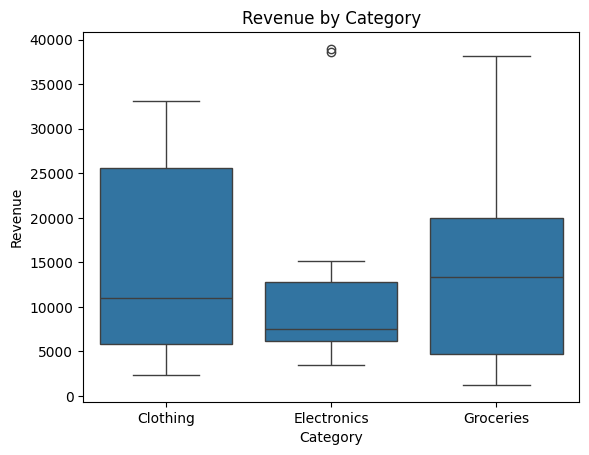

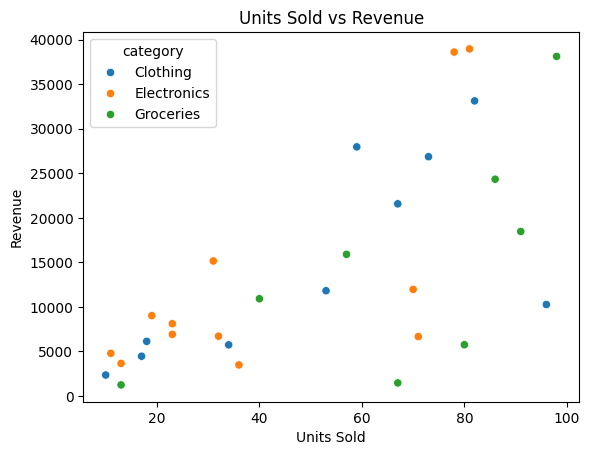

In [3]:
#Submitted Solution

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Create Sample Data
# -----------------------------
np.random.seed(1)

df = pd.DataFrame({
    "date": pd.date_range("2025-01-01", periods=30),
    "category": np.random.choice(
        ["Electronics", "Clothing", "Groceries"], 30
    ),
    "units_sold": np.random.randint(10, 100, 30),
    "discount_pct": np.random.randint(5, 30, 30)
})

# Create revenue column
df["revenue"] = df["units_sold"] * np.random.randint(20, 500, 30)

# -----------------------------
# Outlier Calculation (IQR)
# -----------------------------
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Revenue outlier bounds → Lower: {lower:.2f}, Upper: {upper:.2f}")

# -----------------------------
# Plot 1: Histogram
# -----------------------------
sns.histplot(df["units_sold"], bins=20)

plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Plot 2: Histogram by Category
# -----------------------------
sns.histplot(
    data=df,
    x="units_sold",
    hue="category",
    bins=20
)

plt.title("Units Sold by Category")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Plot 3: Box Plot
# -----------------------------
sns.boxplot(
    data=df,
    x="category",
    y="revenue"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

# -----------------------------
# Plot 4: Scatter Plot
# -----------------------------
sns.scatterplot(
    data=df,
    x="units_sold",
    y="revenue",
    hue="category"
)

plt.title("Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()

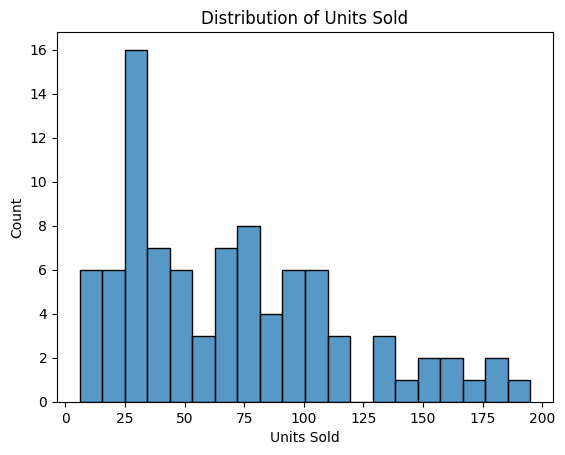

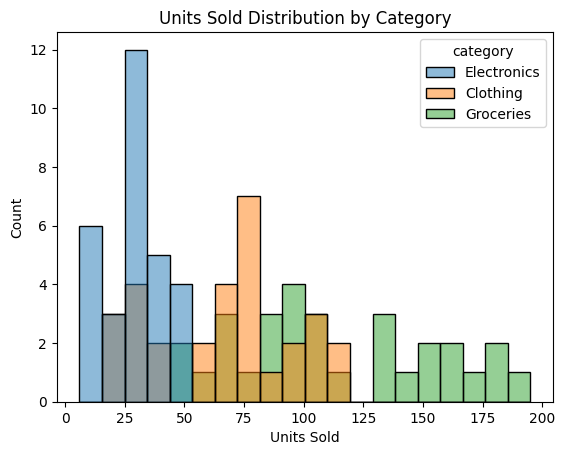

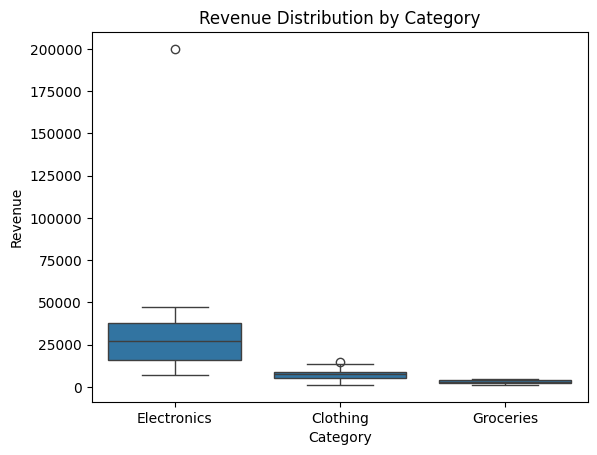

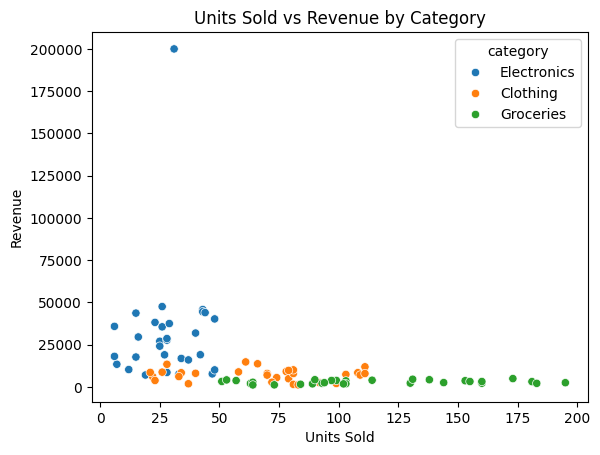

Revenue outlier bounds → Lower: -15551.75, Upper: 34398.25


In [6]:
#Masai Solution

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n = 90
df = pd.DataFrame({
    "category": ["Electronics"] * 30 + ["Clothing"] * 30 + ["Groceries"] * 30,
    "units_sold": (
        list(np.random.randint(5, 50, 30)) +
        list(np.random.randint(20, 120, 30)) +
        list(np.random.randint(50, 200, 30))
    ),
    "revenue": (
        list(np.random.randint(5000, 50000, 29)) + [200000] +
        list(np.random.randint(1000, 15000, 30)) +
        list(np.random.randint(500, 5000, 30))
    ),
})

sns.histplot(data=df, x="units_sold", bins=20)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()

sns.histplot(data=df, x="units_sold", bins=20, hue="category")
plt.title("Units Sold Distribution by Category")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()

sns.boxplot(data=df, x="category", y="revenue")
plt.title("Revenue Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

sns.scatterplot(data=df, x="units_sold", y="revenue", hue="category")
plt.title("Units Sold vs Revenue by Category")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()

Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Revenue outlier bounds → Lower: {lower:.2f}, Upper: {upper:.2f}")
